# Project FORESIGHT — Phase 9: Stability, Residual & Horizon Analysis

Phase 8 LightGBM is **frozen**. This notebook evaluates walk-forward stability,
residuals, recursive horizons, zero-demand behavior, and store variation.

Do not train production replacements here.


## 1. Load Phase 9 artifacts

In [1]:
import os, sys, json
import pandas as pd
from IPython.display import Image, display, Markdown

BASE_DIR = os.path.abspath(".")
if os.path.basename(BASE_DIR) == "notebooks":
    BASE_DIR = os.path.abspath("..")
if BASE_DIR not in sys.path:
    sys.path.insert(0, BASE_DIR)

from src.phase9_common import PHASE9_DIR, FIGURES_DIR, METADATA_PATH, PHASE8_TEST
from src.validate_phase9 import run_validation

folds = pd.read_parquet(os.path.join(PHASE9_DIR, "walk_forward_folds.parquet"))
wf_sum = pd.read_parquet(os.path.join(PHASE9_DIR, "walk_forward_summary.parquet"))
overall = pd.read_parquet(os.path.join(PHASE9_DIR, "residual_overall.parquet"))
regimes = pd.read_parquet(os.path.join(PHASE9_DIR, "residual_by_regime.parquet"))
zero = pd.read_parquet(os.path.join(PHASE9_DIR, "zero_demand.parquet"))
entities = pd.read_parquet(os.path.join(PHASE9_DIR, "entity_metrics.parquet"))
hsum = pd.read_parquet(os.path.join(PHASE9_DIR, "horizon_summary.parquet"))
diag = pd.read_parquet(os.path.join(PHASE9_DIR, "residual_diagnostics.parquet"))
meta = json.load(open(METADATA_PATH, encoding="utf-8"))
print("Phase 8 frozen WAPE", PHASE8_TEST)
print("walk-forward summary:")
print(wf_sum.to_string(index=False))
print("phase8_unchanged", meta.get("phase8_unchanged"))
print("conclusion", meta["conclusion"]["option"], meta["conclusion"]["label"])


Phase 8 frozen WAPE {'UCI': {'model': 'lightgbm', 'MAE': 17.3447, 'RMSE': 70.8952, 'sMAPE': 82.8734, 'WAPE': 79.471}, 'SYNTHETIC': {'model': 'lightgbm', 'MAE': 2.8156, 'RMSE': 5.1469, 'sMAPE': 113.6813, 'WAPE': 38.8923}}
walk-forward summary:
source_dataset stability_label  cv_wape  range_ratio  mean_wape  std_wape  min_wape  max_wape  mean_mae  mean_rmse  mean_smape  mean_bias                                       reason
           UCI          Stable   0.1354       1.3691    85.3126   11.5479   76.9218  105.3143   17.3293    72.5814     83.6684     1.1996 CV_WAPE=0.135 < 0.15 and max/min=1.369 < 1.5
     SYNTHETIC          Stable   0.0132       1.0370    39.3940    0.5186   38.6743   40.1044    2.8830     5.3249    116.8050     0.0314 CV_WAPE=0.013 < 0.15 and max/min=1.037 < 1.5
phase8_unchanged True
conclusion B Moderately Stable


## 2. Walk-forward folds

source_dataset  fold  train_end  val_start    val_end  train_rows  val_rows     MAE    RMSE    sMAPE     WAPE    bias  overprediction_pct  underprediction_pct
           UCI     1 2010-07-13 2010-07-14 2010-12-31      142504    131081 19.0763 91.5864  84.2453  83.8348  0.3652               71.41                28.59
           UCI     2 2010-12-31 2011-01-01 2011-04-30      273585     74220 18.3322 92.7428  86.8999 105.3143  5.5927               76.01                23.99
           UCI     3 2011-04-30 2011-05-01 2011-07-13      347805     49142 15.6943 52.5210  84.1959  82.4168  1.2356               74.13                25.87
           UCI     4 2011-07-13 2011-07-14 2011-09-25      396947     53020 16.5035 55.8952  80.2343  76.9218 -1.0227               70.65                29.35
           UCI     5 2011-09-25 2011-09-26 2011-12-09      449967     79545 17.0402 70.1618  82.7665  78.0755 -0.1727               72.01                27.99
     SYNTHETIC     1 2023-12-31 2024-01-01 202

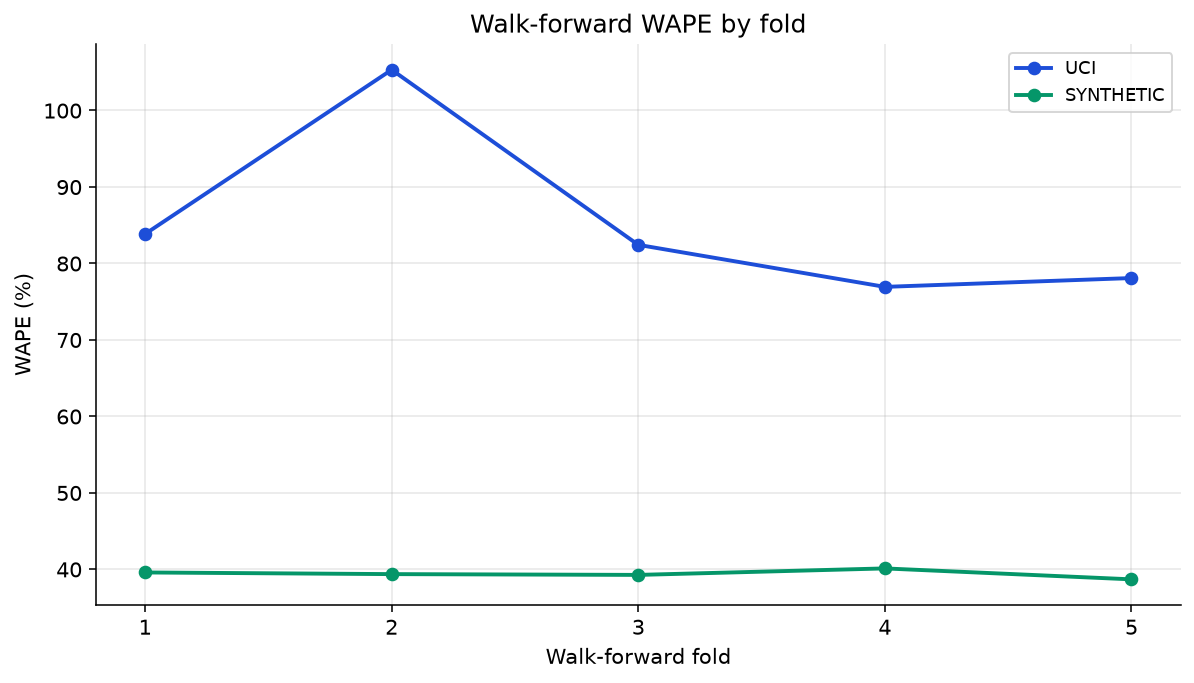

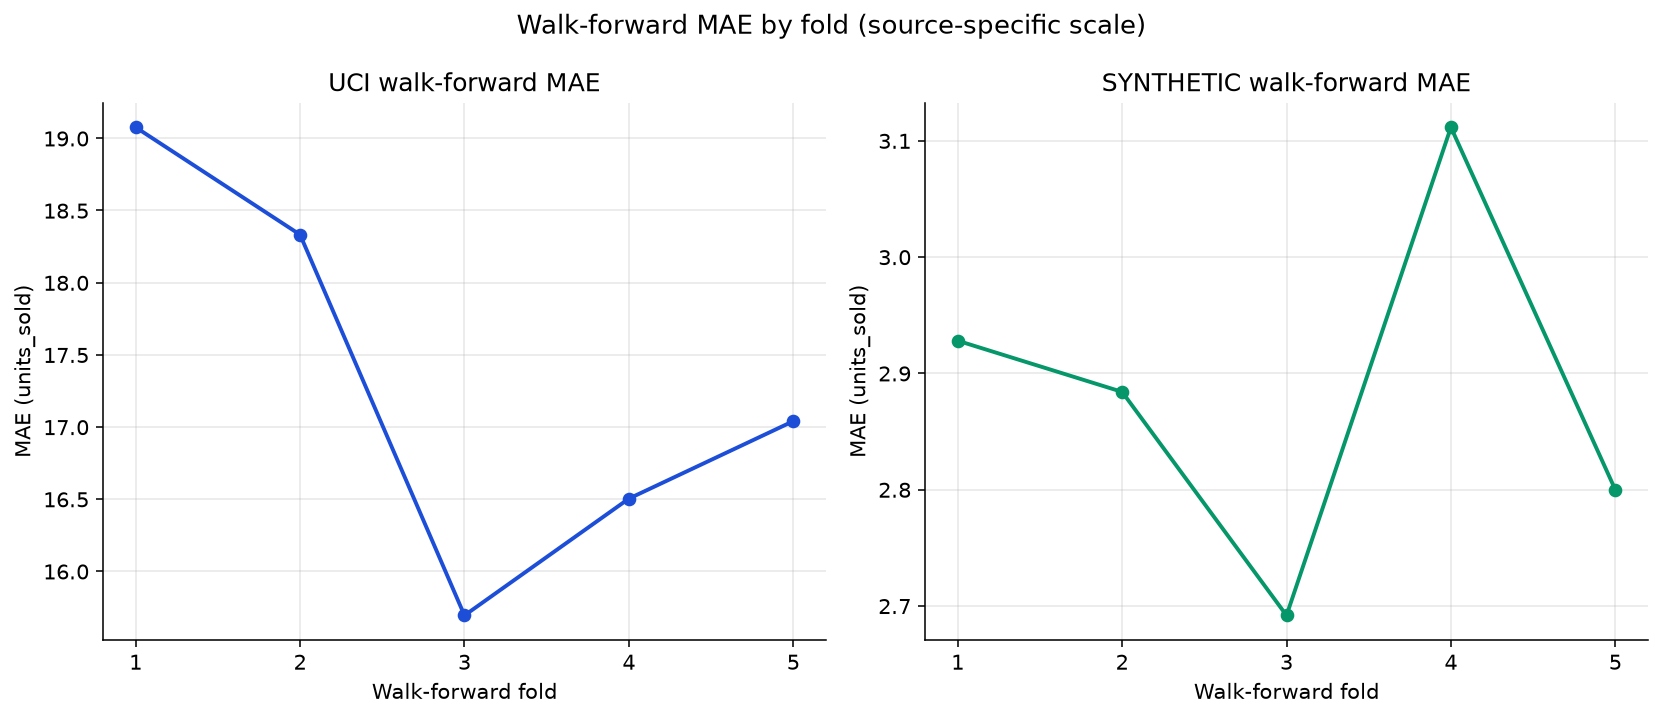

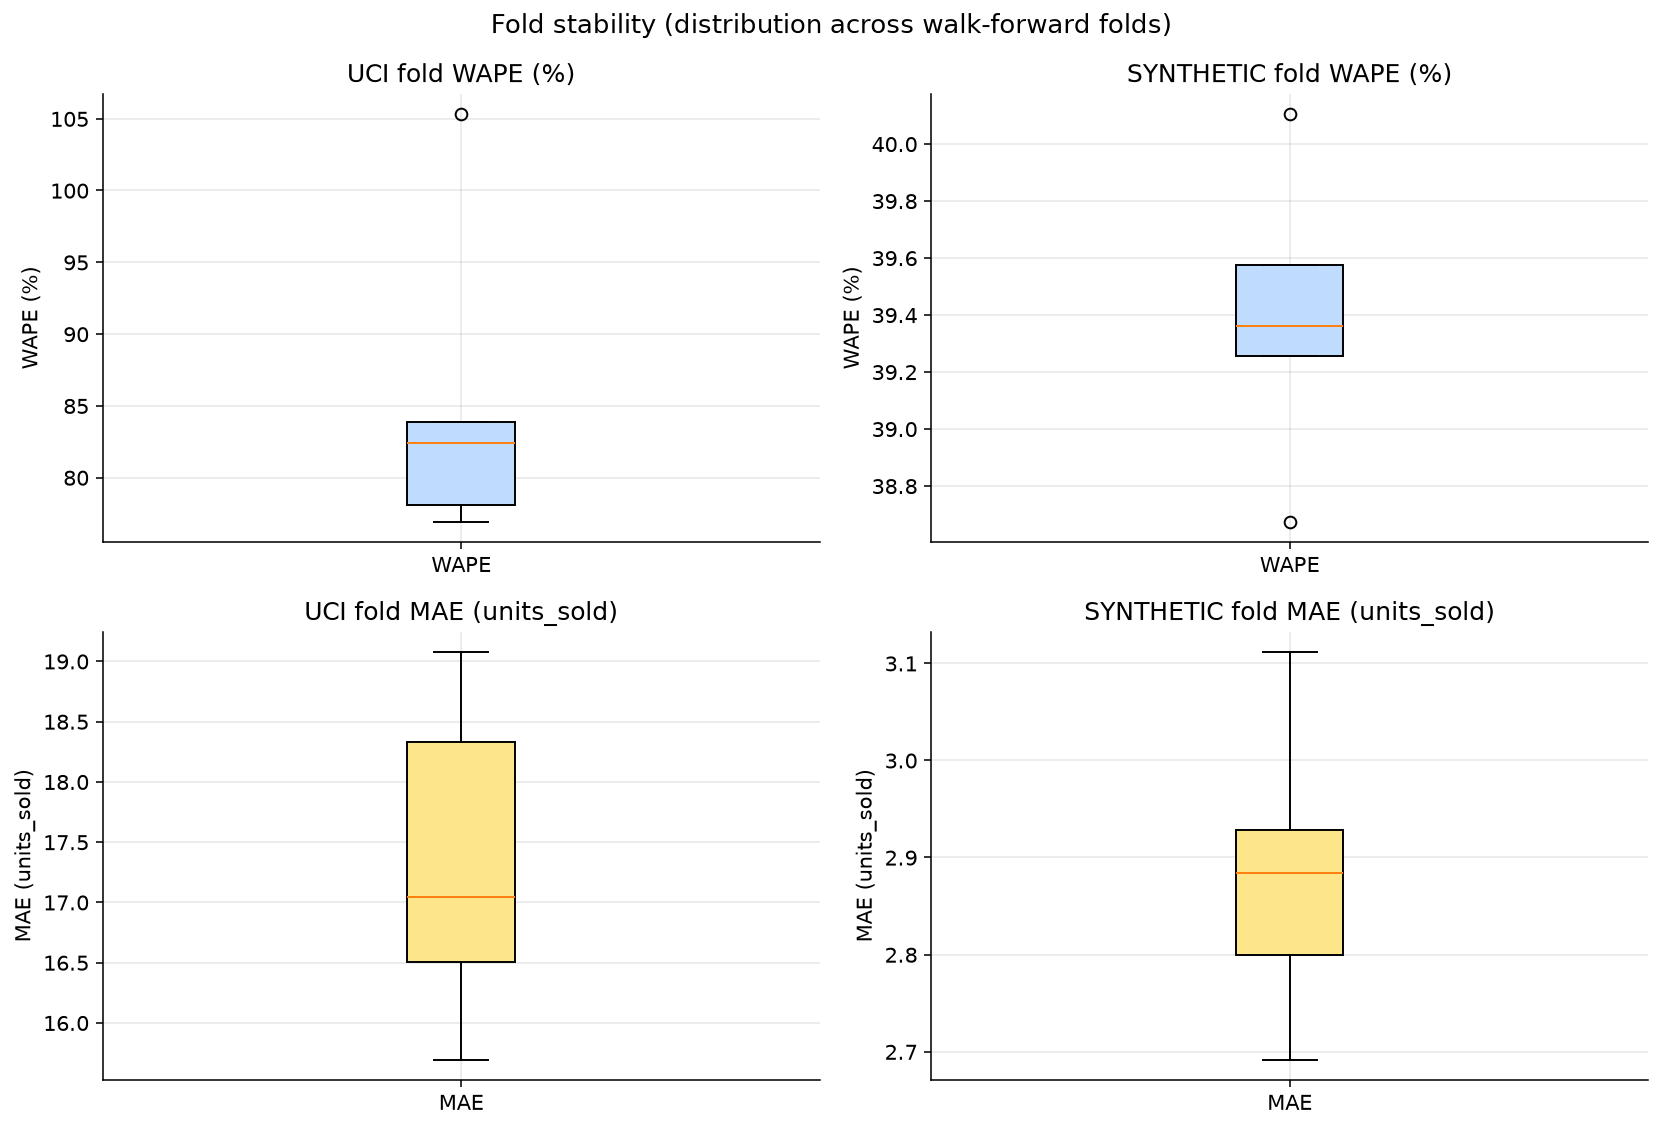

In [2]:
print(folds[[
    "source_dataset","fold","train_end","val_start","val_end",
    "train_rows","val_rows","MAE","RMSE","sMAPE","WAPE","bias",
    "overprediction_pct","underprediction_pct"
]].to_string(index=False))
assert folds.groupby("source_dataset")["fold"].nunique().min() == 5
assert (pd.to_datetime(folds.train_end_actual) < pd.to_datetime(folds.val_start_actual)).all()
print("Chronology OK")
display(Image(os.path.join(FIGURES_DIR, "walk_forward_wape.png")))
display(Image(os.path.join(FIGURES_DIR, "walk_forward_mae.png")))
display(Image(os.path.join(FIGURES_DIR, "fold_stability.png")))


## 3. Residual overview

source_dataset      n     MAE    RMSE    sMAPE    WAPE     MAPE   bias  mean_residual  median_residual  residual_std  overprediction_pct  underprediction_pct
     SYNTHETIC 147000  2.8156  5.1469 113.6813 38.8923  30.4648 0.0873        -0.0873          -0.5393        5.1461               67.24                22.12
           UCI  79545 17.3447 70.8952  82.8734 79.4710 283.0189 0.0335        -0.0335          -3.8346       70.8956               71.72                28.28

regimes:
source_dataset demand_regime     n  n_share_pct  mean_actual  mean_prediction     MAE     RMSE    sMAPE     WAPE     bias  overprediction_pct  underprediction_pct  q33_positive  q66_positive
     SYNTHETIC          high 17723        12.06      31.8255          25.2808  8.2840  11.6919  33.6972  26.0294  -6.5447               23.28                76.72          13.0          22.0
     SYNTHETIC           low 21135        14.38       8.5730           9.6583  2.8395   3.8457  33.9435  33.1215   1.0853             

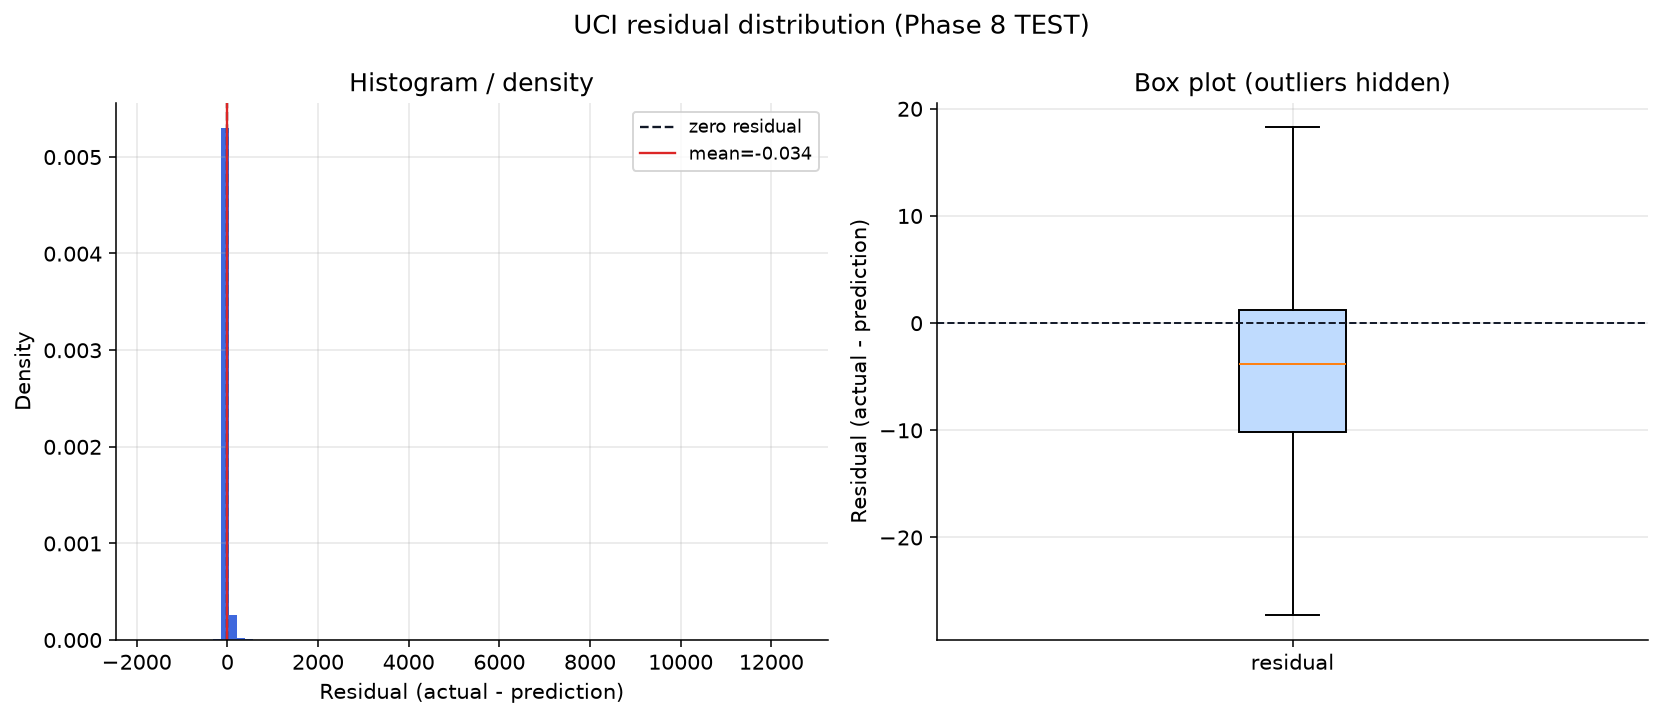

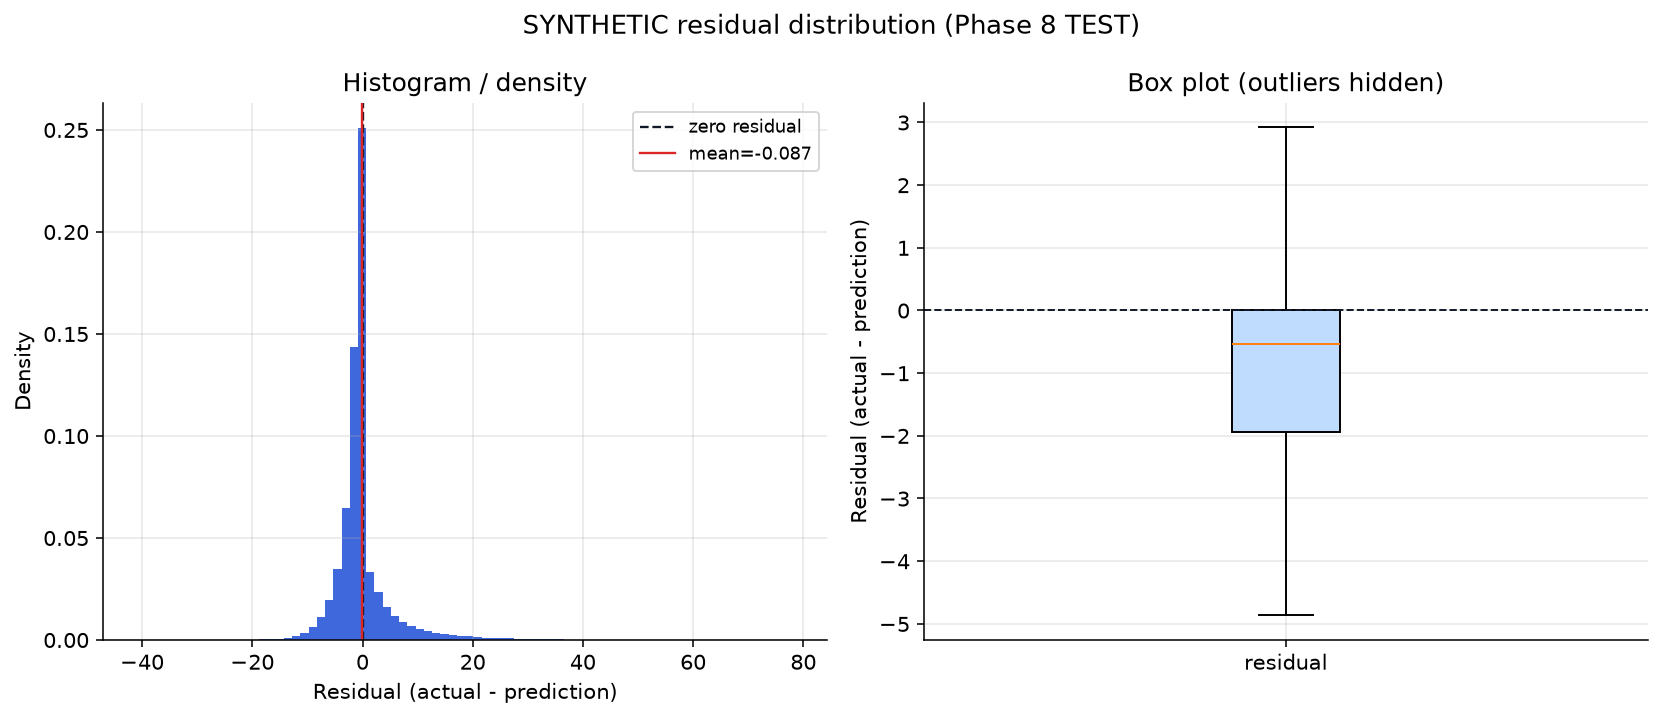

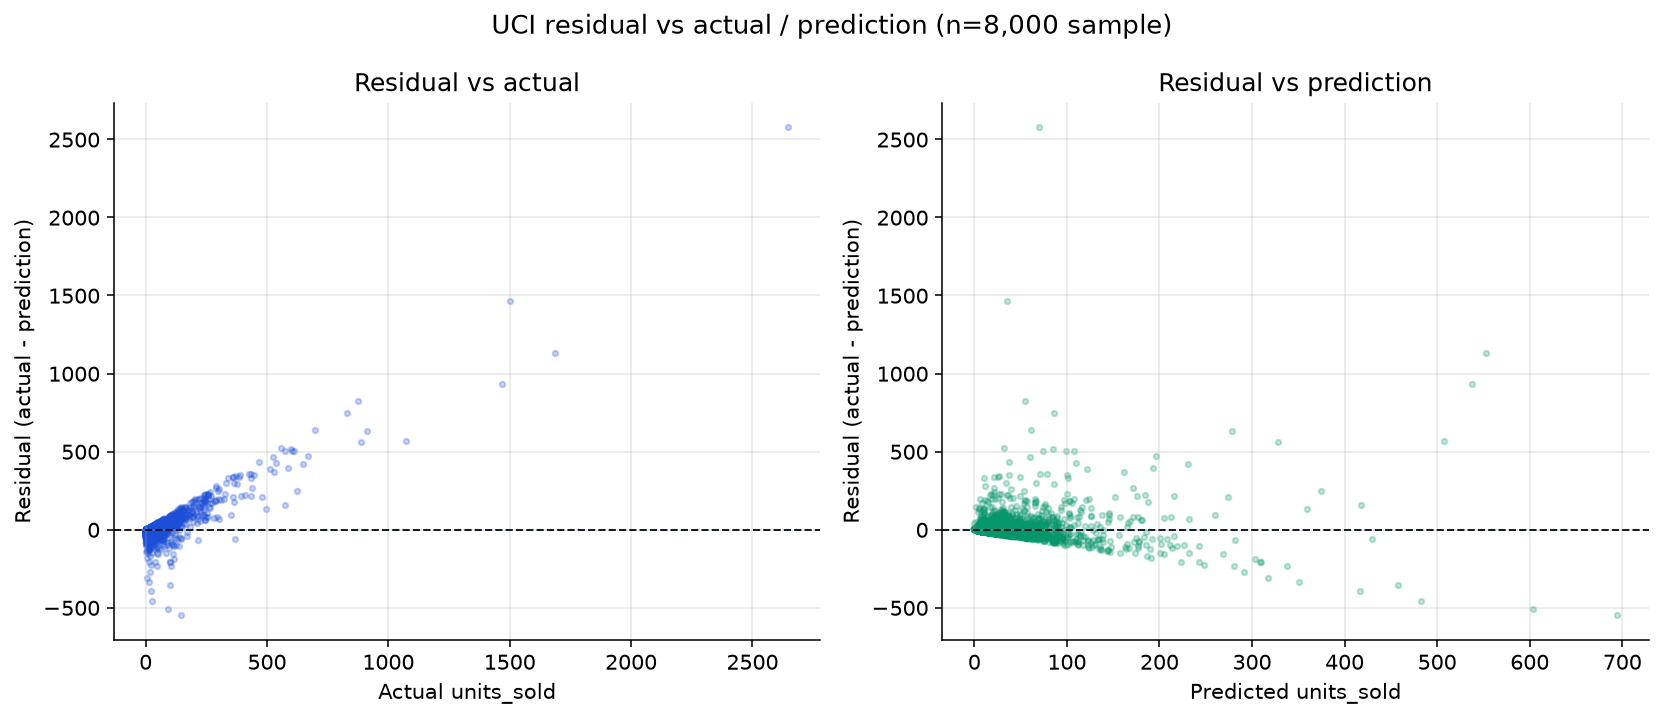

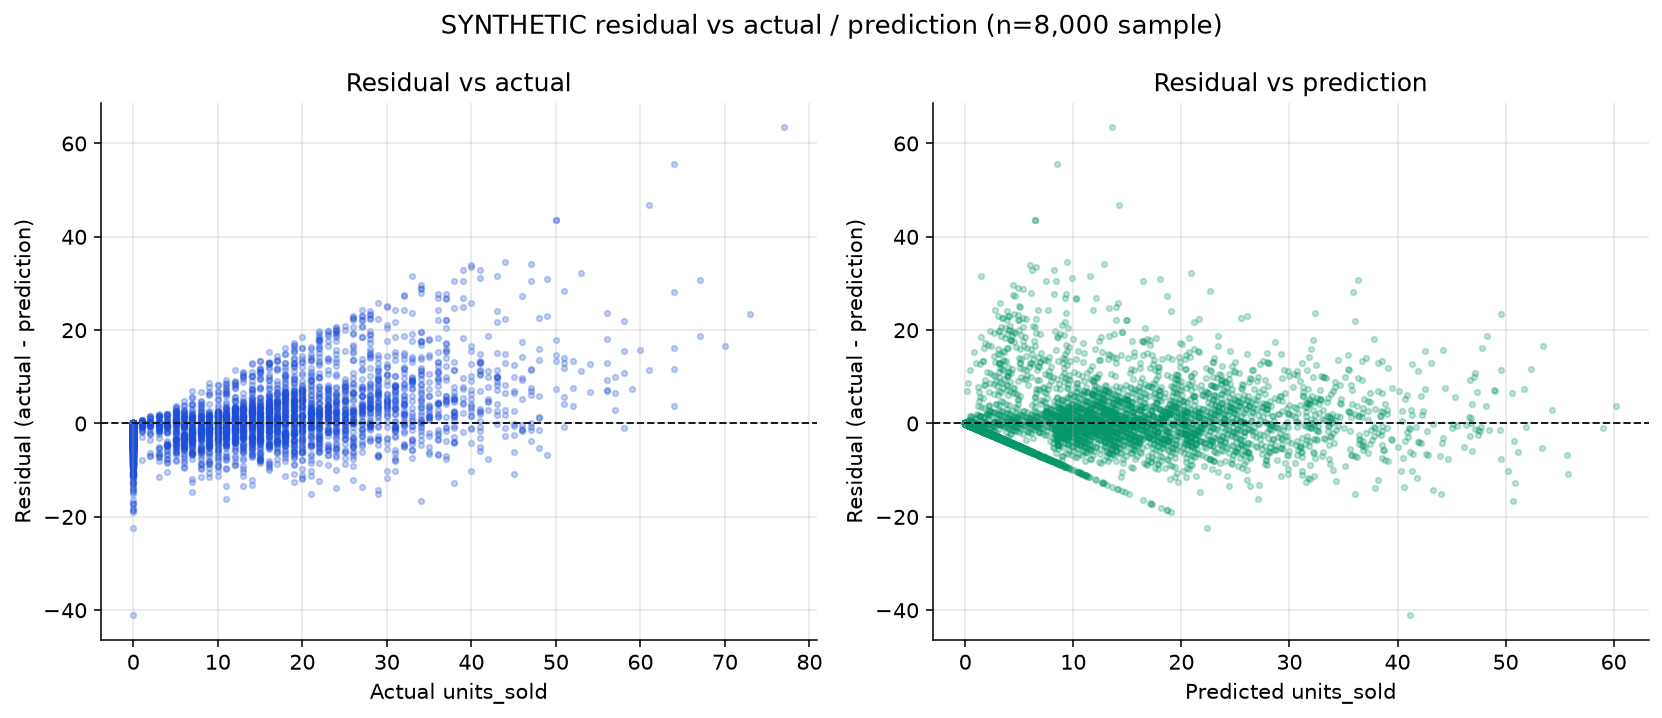

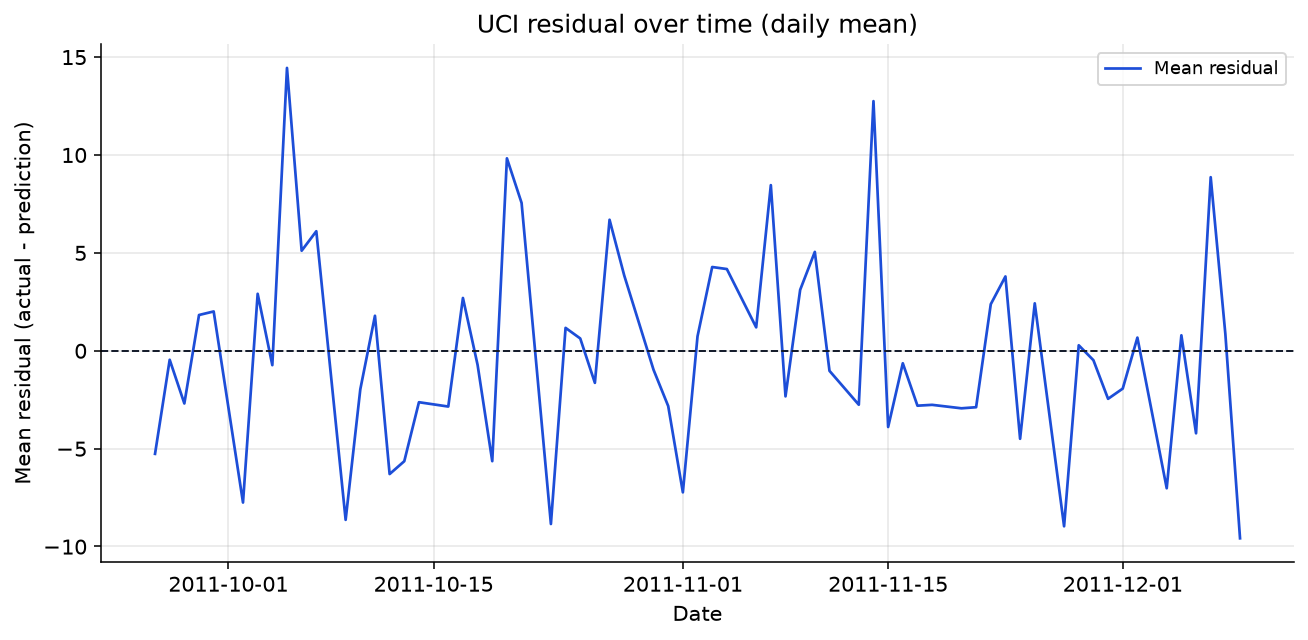

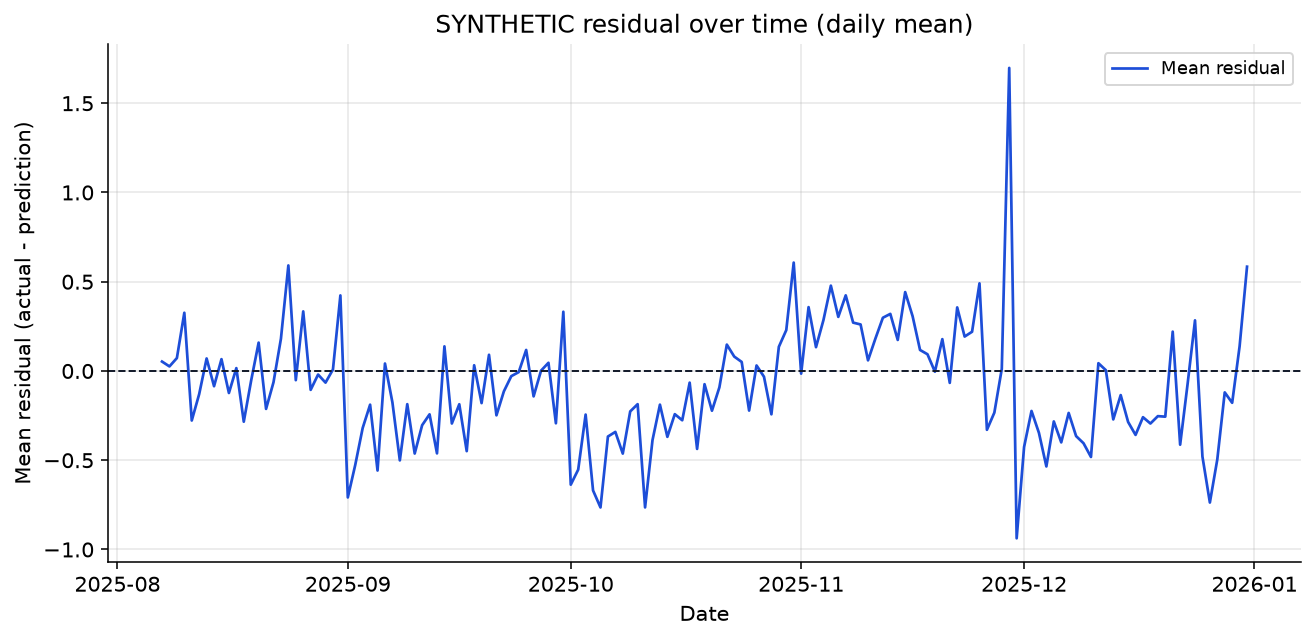

In [3]:
print(overall.to_string(index=False))
print("\nregimes:")
print(regimes.to_string(index=False))
print("\ndiagnostics:")
print(diag.to_string(index=False))
display(Image(os.path.join(FIGURES_DIR, "residual_distribution_uci.png")))
display(Image(os.path.join(FIGURES_DIR, "residual_distribution_synthetic.png")))
display(Image(os.path.join(FIGURES_DIR, "residual_vs_actual_uci.png")))
display(Image(os.path.join(FIGURES_DIR, "residual_vs_actual_synthetic.png")))
display(Image(os.path.join(FIGURES_DIR, "residual_over_time_uci.png")))
display(Image(os.path.join(FIGURES_DIR, "residual_over_time_synthetic.png")))


## 4. Zero-demand

source_dataset  n_total  n_zero  n_nonzero  zero_share_pct  zero_actual_prediction_mae  zero_actual_mean_prediction  zero_actual_median_prediction  zero_actual_positive_prediction_rate  zero_WAPE  zero_sMAPE  nonzero_MAE  nonzero_RMSE  nonzero_WAPE  nonzero_sMAPE  nonzero_mean_actual  nonzero_mean_prediction  counts_reconcile
     SYNTHETIC   147000   90070      56930           61.27                      1.4444                       1.4444                         0.7548                                 82.64        0.0    165.2759       4.9850        7.6438       26.6677        32.0524              18.6932                  16.6336                 1
           UCI    79545       0      79545            0.00                         NaN                          NaN                            NaN                                   NaN        NaN         NaN      17.3447       70.8952       79.4710        82.8734              21.8252                  21.8588                 1
Zero-demand coun

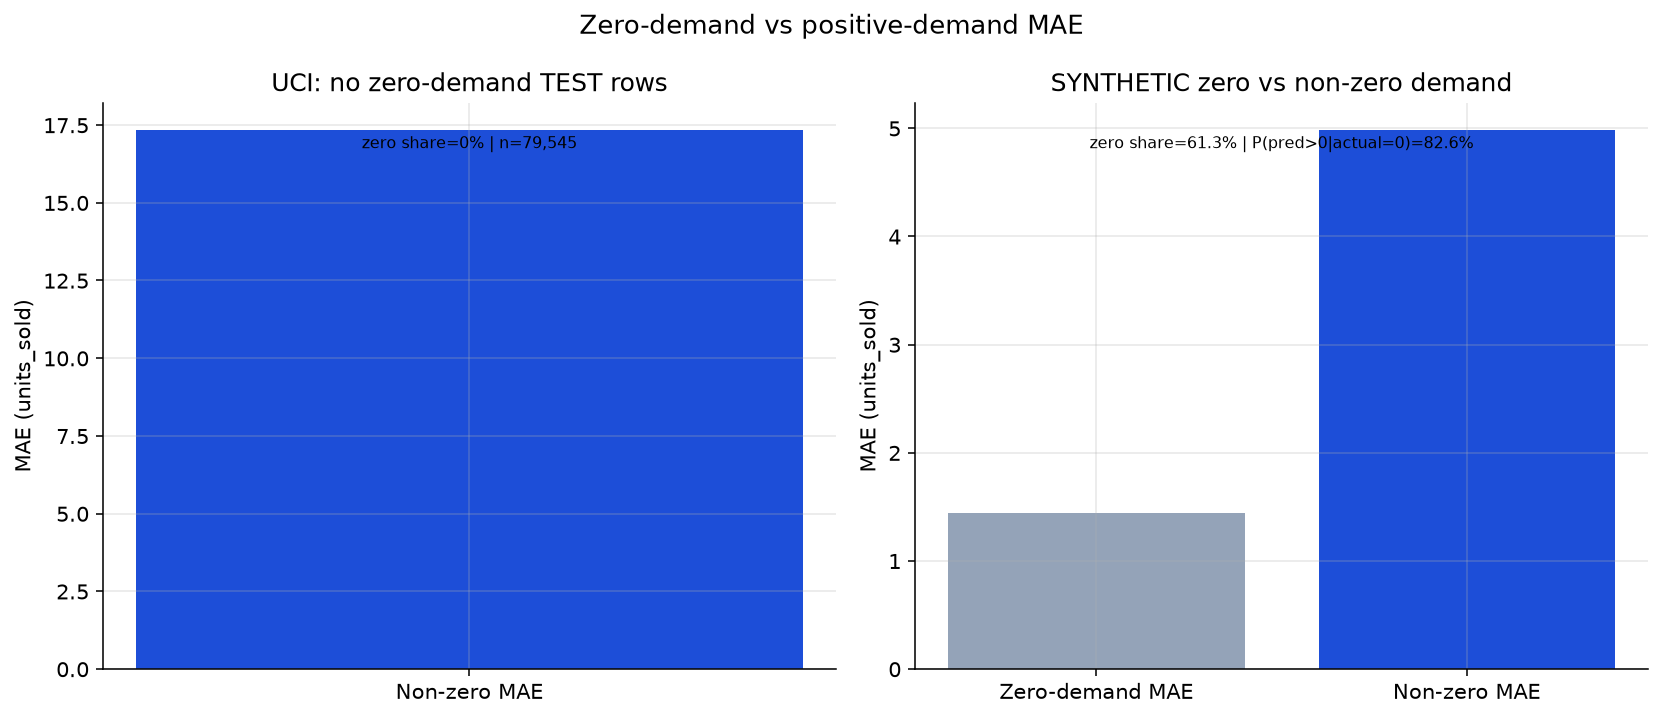

In [4]:
print(zero.to_string(index=False))
for _, r in zero.iterrows():
    assert int(r.n_zero) + int(r.n_nonzero) == int(r.n_total)
print("Zero-demand counts reconcile")
display(Image(os.path.join(FIGURES_DIR, "zero_demand_analysis.png")))


## 5. Horizon table

source_dataset  horizon     n     MAE     RMSE    sMAPE     WAPE    bias
     SYNTHETIC        1 21000  4.1399   7.1323 127.4303  64.3163  0.1631
     SYNTHETIC        3 21000  8.1481  13.1673 145.1359  82.8176 -0.2312
     SYNTHETIC        7 21000  7.4099  11.2998 151.6665 112.0417  0.4548
     SYNTHETIC       14 20000  7.3424  11.2173 153.7303 111.5234  0.2880
     SYNTHETIC       30 17000  6.5509  10.3880 155.4533 100.9901 -0.7547
           UCI        1  4839 28.5693  77.8076  76.9311  79.4761 -2.4823
           UCI        3  4759 29.6548  66.6666  76.6289  79.5917 -1.6682
           UCI        7  4439 33.9680 111.0133  80.6896  89.7171 -0.3643
           UCI       14  3875 37.2220 116.8579  81.3363  96.4946  0.7922
           UCI       30  2595 38.8311  91.6766  82.7562 100.2543  2.0394
supported horizons [1, 3, 7, 14, 30]


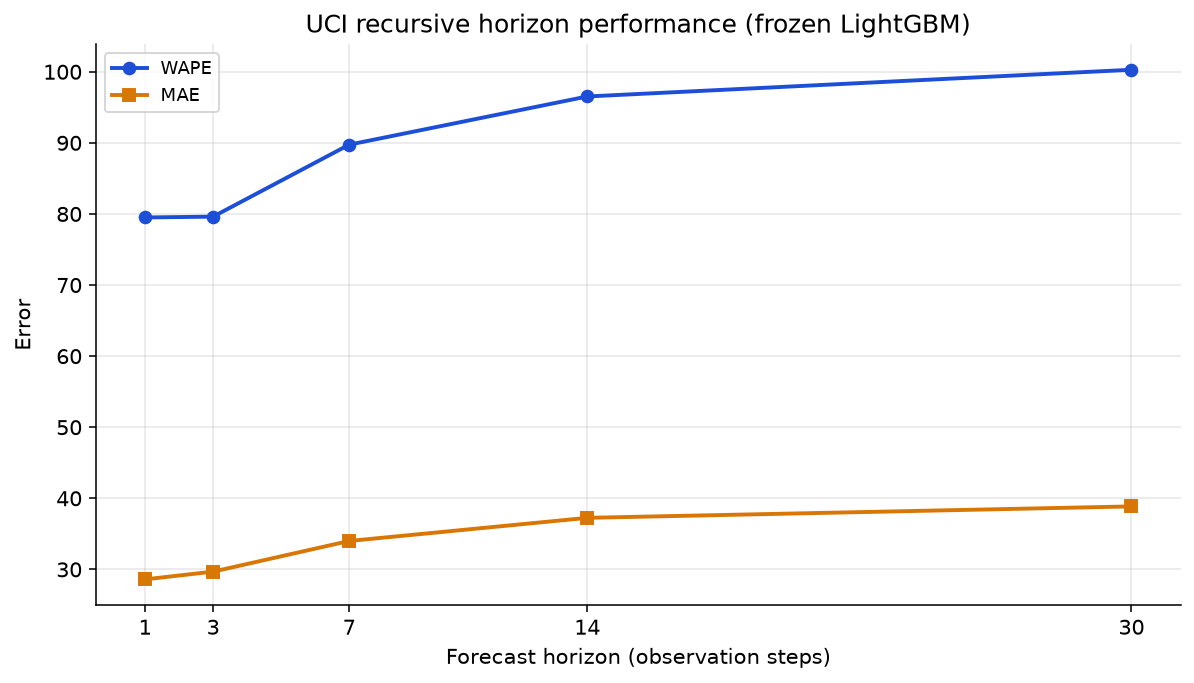

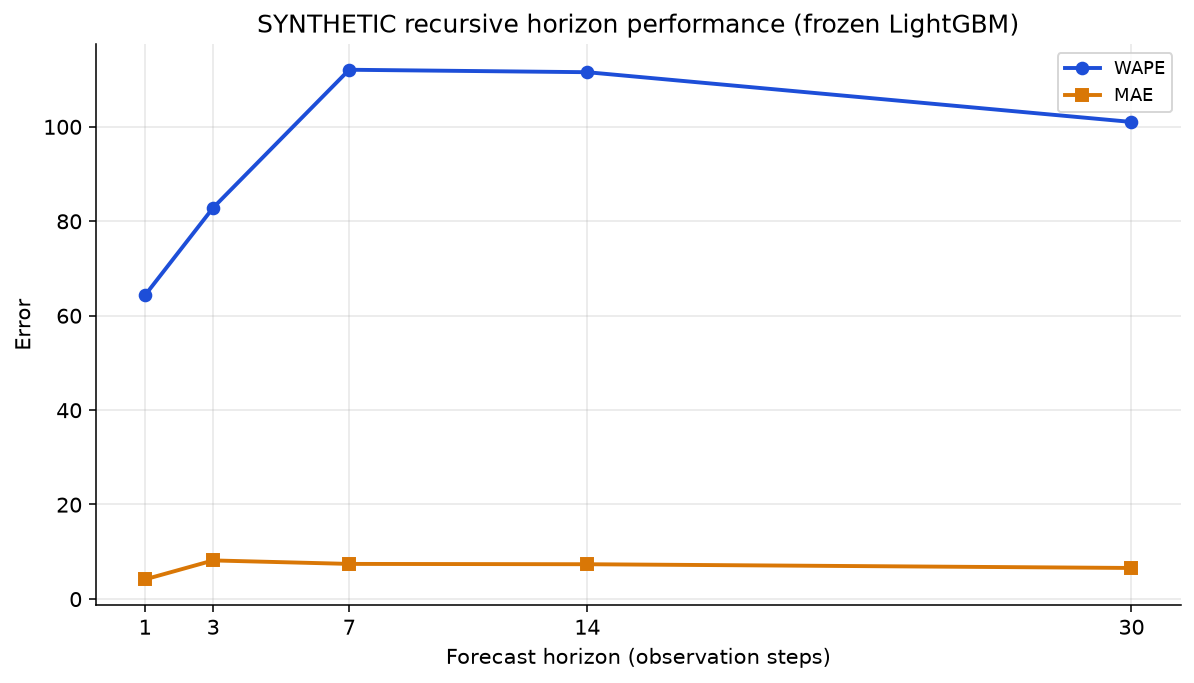

In [5]:
print(hsum.to_string(index=False))
print("supported horizons", sorted(hsum.horizon.unique().tolist()))
display(Image(os.path.join(FIGURES_DIR, "horizon_performance_uci.png")))
display(Image(os.path.join(FIGURES_DIR, "horizon_performance_synthetic.png")))


## 6. Store stability

entity_id     n    MAE   RMSE    WAPE   bias
STORE_005 14700 2.7886 5.0175 37.8151 0.0782
STORE_009 14700 2.7362 4.9127 38.0589 0.1256
STORE_001 14700 2.7713 5.1224 38.1943 0.0959
STORE_006 14700 2.8593 5.2000 38.4936 0.0877
STORE_002 14700 2.7693 5.0403 38.8348 0.1258
STORE_008 14700 2.9047 5.3696 38.8528 0.0397
STORE_007 14700 2.8874 5.3858 39.1453 0.0206
STORE_004 14700 2.9101 5.3979 39.2797 0.0566
STORE_010 14700 2.7314 4.8924 40.1581 0.1377
STORE_003 14700 2.7978 5.0986 40.2323 0.1055
best STORE_005 37.8151
worst STORE_003 40.2323


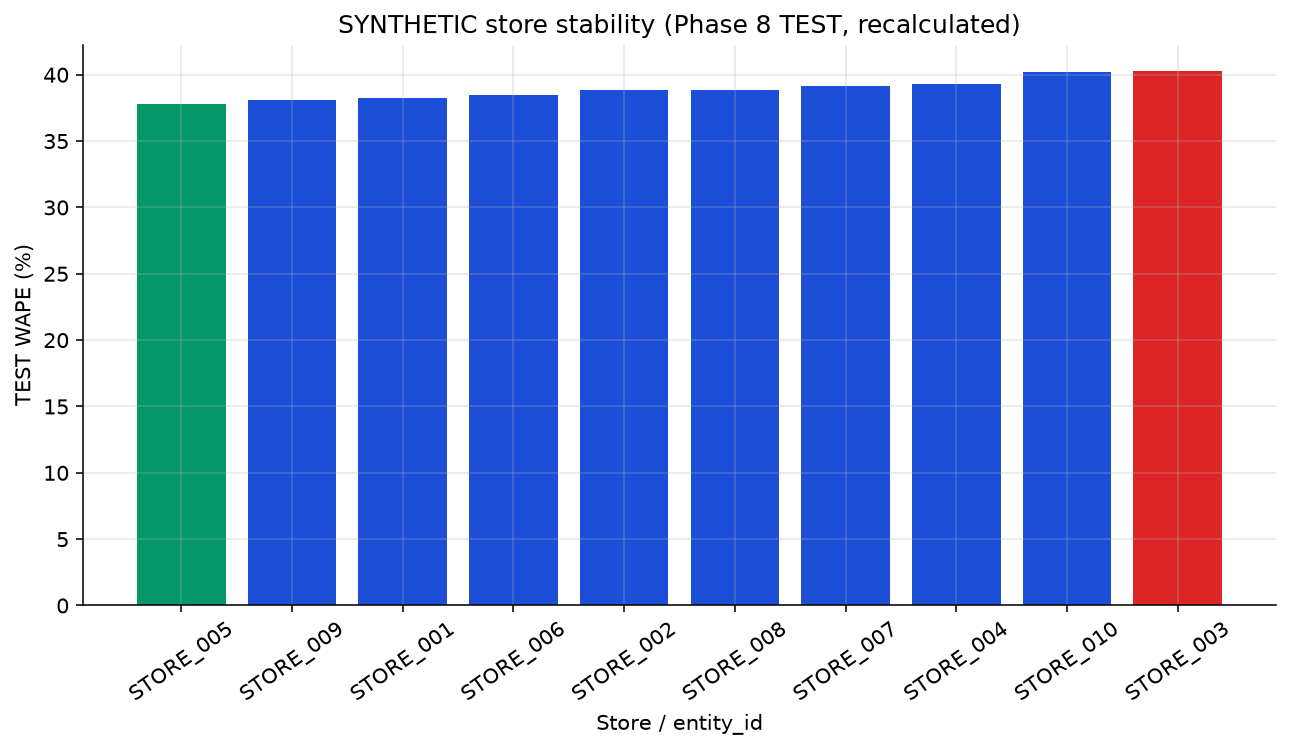

In [6]:
syn = entities[entities.source_dataset=="SYNTHETIC"].sort_values("WAPE")
print(syn[["entity_id","n","MAE","RMSE","WAPE","bias"]].to_string(index=False))
print("best", syn.iloc[0].entity_id, syn.iloc[0].WAPE)
print("worst", syn.iloc[-1].entity_id, syn.iloc[-1].WAPE)
display(Image(os.path.join(FIGURES_DIR, "store_stability.png")))


## 7. Figures present

In [7]:
figs = sorted(os.listdir(FIGURES_DIR))
print("\n".join(figs))
assert "walk_forward_wape.png" in figs
assert "store_stability.png" in figs
assert "horizon_performance_uci.png" in figs
assert "horizon_performance_synthetic.png" in figs


fold_stability.png
horizon_performance_synthetic.png
horizon_performance_uci.png
residual_distribution_synthetic.png
residual_distribution_uci.png
residual_over_time_synthetic.png
residual_over_time_uci.png
residual_vs_actual_synthetic.png
residual_vs_actual_uci.png
store_stability.png
walk_forward_mae.png
walk_forward_wape.png
zero_demand_analysis.png


## 8. Validation

In [8]:
result = run_validation()
print("VALIDATION", result.summary())
assert result.failed == 0
print("Phase 9 COMPLETE — STOP before Phase 10.")
print("Conclusion:", meta["conclusion"]["option"], meta["conclusion"]["label"])
print(meta["conclusion"]["statement"])


PHASE 9 VALIDATION

[1] Phase 8 freeze / data integrity
  [+] Phase 6 features exist
  [+] Phase 8 predictions exist


  [+] Phase 6 dates parse
  [+] Phase 6 grain columns present


  [+] UCI series dates chronologically ordered


  [+] SYNTHETIC series dates chronologically ordered
  [+] phase9_metadata.json exists
  [+] Phase 8 artifacts unchanged vs Phase 9 snapshot -- []
  [+] Metadata records phase8_unchanged True
  [+] Phase 8 pred column date
  [+] Phase 8 pred column source_dataset
  [+] Phase 8 pred column entity_id
  [+] Phase 8 pred column product_key
  [+] Phase 8 pred column actual_units_sold
  [+] Phase 8 pred column predicted_units_sold
  [+] Prediction dates parse

[2] Output artifacts
  [+] Report exists
  [+] Notebook exists -- C:\Users\SURAG\Documents\zidio\Project_FORESIGHT\Demand-Inventory-Intelligence\notebooks\08_phase9_stability_residual_horizon.ipynb
  [+] parquet walk_forward_folds.parquet
  [+] parquet walk_forward_summary.parquet
  [+] parquet residual_overall.parquet
  [+] parquet residual_by_regime.parquet
  [+] parquet zero_demand.parquet
  [+] parquet entity_metrics.parquet
  [+] parquet residual_diagnostics.parquet
  [+] parquet horizon_detail.parquet
  [+] parquet horizon_summar

  [+] UCI regime n sums to source n -- 79545 vs 79545
  [+] SYNTHETIC regime n sums to source n -- 147000 vs 147000

[10] Metadata completeness
  [+] metadata.python_version
  [+] metadata.packages
  [+] metadata.random_state
  [+] metadata.fold_definitions
  [+] metadata.horizon_definitions
  [+] metadata.metric_definitions
  [+] metadata.conclusion
  [+] conclusion.option in {A,B,C}
  [+] conclusion.label present

VALIDATION RESULT: 146/146 PASS
VALIDATION 146/146 PASS
Phase 9 COMPLETE — STOP before Phase 10.
Conclusion: B Moderately Stable
LightGBM is promising but requires targeted improvements before productionization.
